In [ ]:
!pip install torch torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


In [ ]:
## 2025-11-02
## Dung GNN tao NodeEmbedding va GraphEmbedding
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

# --- 1. CHUẨN BỊ DỮ LIỆU (PyTorch Geometric Data Object) ---

# Định nghĩa các đặc trưng (features) cho 3 nodes
# x: Tensor có kích thước (số_nodes, số_đặc_trưng)
x = torch.tensor([[-1.], [0.], [1.]], dtype=torch.float)

# Định nghĩa các cạnh (edges)
# edge_index: Tensor có kích thước (2, số_cạnh)
# Cạnh (0, 1), (1, 0), (1, 2), (2, 1)
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)

# Tạo đối tượng Data
data = Data(x=x, edge_index=edge_index)

print("--- 1. Thông tin Dữ liệu Đồ thị ---")
print(data)
print(f"Số lượng nodes: {data.num_nodes}")
print(f"Số lượng đặc trưng node ban đầu: {data.num_node_features}")

# --- 2. ĐỊNH NGHĨA MÔ HÌNH GNN CHO NODE EMBEDDINGS ---

class GNN_Node_Embed(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # Lớp GCN thứ nhất
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Lớp GCN thứ hai. Đầu ra chính là Node Embeddings (out_channels = node_embedding_dim)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Lớp 1: Propagate -> Transform -> Non-linearity -> Regularization
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # Lớp 2: Tính Node Embeddings
        node_embeddings = self.conv2(x, edge_index)
        return node_embeddings

# --- 3. ĐỊNH NGHĨA MÔ HÌNH GNN CHO GRAPH EMBEDDING (Bao gồm Pooling) ---

class GNN_Graph_Embed(GNN_Node_Embed):
    """Kế thừa GNN_Node_Embed và thêm lớp Pooling."""
    def __init__(self, in_channels, hidden_channels, node_embed_dim, graph_embed_dim):
        super().__init__(in_channels, hidden_channels, node_embed_dim)
        # Lớp Linear sau Pooling (tùy chọn) để điều chỉnh kích thước Graph Embedding
        self.lin = torch.nn.Linear(node_embed_dim, graph_embed_dim)

    def forward(self, x, edge_index, batch):
        # 1. Tính Node Embeddings (sử dụng forward của lớp cha)
        node_embeddings = super().forward(x, edge_index)

        # 2. Global Pooling: Gộp Node Embeddings thành một Graph Embedding
        # global_mean_pool: tính trung bình các Node Embeddings trong mỗi đồ thị (được chỉ định bởi tensor 'batch')
        pooled_embedding = global_mean_pool(node_embeddings, batch)

        # 3. Lớp Linear để ra kích thước Graph Embedding cuối cùng
        graph_embedding = self.lin(pooled_embedding)

        return node_embeddings, graph_embedding

# --- 4. KHỞI TẠO VÀ TÍNH TOÁN ---

# Cấu hình kích thước
IN_CHANNELS = data.num_node_features  # 1
HIDDEN_CHANNELS = 16
NODE_EMBED_DIM = 8  # Kích thước Node Embeddings mong muốn
GRAPH_EMBED_DIM = 4 # Kích thước Graph Embedding mong muốn

model = GNN_Graph_Embed(IN_CHANNELS, HIDDEN_CHANNELS, NODE_EMBED_DIM, GRAPH_EMBED_DIM)

# Chuẩn bị tensor 'batch'
# Vì chỉ có 1 đồ thị, tất cả nodes (3 nodes) đều thuộc đồ thị (batch index) 0.
batch = torch.zeros(data.num_nodes, dtype=torch.long)

# Tính toán Embeddings
model.eval() # Đặt mô hình ở chế độ đánh giá
with torch.no_grad():
    node_embeddings_result, graph_embedding_result = model(data.x, data.edge_index, batch)

# --- 5. HIỂN THỊ KẾT QUẢ ---

print("\n--- 2. Node Embeddings (Đầu ra của conv2) ---")
print(f"Kích thước Node Embeddings: {node_embeddings_result.shape} (Số_Nodes, Kích_thước_Embedding_Node)")
print(node_embeddings_result)

print("\n--- 3. Graph Embedding (Đầu ra của Pooling + Linear) ---")
print(f"Kích thước Graph Embedding: {graph_embedding_result.shape} (Số_Đồ_thị, Kích_thước_Embedding_Đồ_thị)")
print(graph_embedding_result)

--- 1. Thông tin Dữ liệu Đồ thị ---
Data(x=[3, 1], edge_index=[2, 4])
Số lượng nodes: 3
Số lượng đặc trưng node ban đầu: 1

--- 2. Node Embeddings (Đầu ra của conv2) ---
Kích thước Node Embeddings: torch.Size([3, 8]) (Số_Nodes, Kích_thước_Embedding_Node)
tensor([[ 0.0442, -0.1007,  0.0869, -0.1300, -0.0759,  0.0104,  0.0411,  0.0211],
        [ 0.0804,  0.0476, -0.0033, -0.1306,  0.0325, -0.0017,  0.0282,  0.0227],
        [ 0.0543,  0.1591, -0.0909, -0.0299,  0.1157, -0.0125, -0.0065,  0.0067]])

--- 3. Graph Embedding (Đầu ra của Pooling + Linear) ---
Kích thước Graph Embedding: torch.Size([1, 4]) (Số_Đồ_thị, Kích_thước_Embedding_Đồ_thị)
tensor([[-0.0134, -0.2424,  0.0367,  0.1899]])


In [ ]:
# Ghi dau ra vao file nodeEmbedding.txt va graphembedding.txt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

# --- 1. CHUẨN BỊ DỮ LIỆU (PyTorch Geometric Data Object) ---

# Định nghĩa các đặc trưng (features) cho 3 nodes
x = torch.tensor([[-1.], [0.], [1.]], dtype=torch.float)

# Định nghĩa các cạnh (edges)
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)

# Tạo đối tượng Data
data = Data(x=x, edge_index=edge_index)

print("--- 1. Thông tin Dữ liệu Đồ thị ---")
print(data)

# --- 2. ĐỊNH NGHĨA MÔ HÌNH GNN CHO NODE EMBEDDINGS ---

class GNN_Node_Embed(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        node_embeddings = self.conv2(x, edge_index)
        return node_embeddings

# --- 3. ĐỊNH NGHĨA MÔ HÌNH GNN CHO GRAPH EMBEDDING (Bao gồm Pooling) ---

class GNN_Graph_Embed(GNN_Node_Embed):
    def __init__(self, in_channels, hidden_channels, node_embed_dim, graph_embed_dim):
        super().__init__(in_channels, hidden_channels, node_embed_dim)
        self.lin = torch.nn.Linear(node_embed_dim, graph_embed_dim)

    def forward(self, x, edge_index, batch):
        # 1. Tính Node Embeddings
        node_embeddings = super().forward(x, edge_index)

        # 2. Global Pooling
        pooled_embedding = global_mean_pool(node_embeddings, batch)

        # 3. Lớp Linear
        graph_embedding = self.lin(pooled_embedding)

        return node_embeddings, graph_embedding

# --- 4. KHỞI TẠO VÀ TÍNH TOÁN EMBEDDINGS ---

# Cấu hình kích thước
IN_CHANNELS = data.num_node_features
HIDDEN_CHANNELS = 16
NODE_EMBED_DIM = 8
GRAPH_EMBED_DIM = 4

model = GNN_Graph_Embed(IN_CHANNELS, HIDDEN_CHANNELS, NODE_EMBED_DIM, GRAPH_EMBED_DIM)

# Tensor 'batch'
batch = torch.zeros(data.num_nodes, dtype=torch.long)

# Tính toán Embeddings
model.eval()
with torch.no_grad():
    node_embeddings_result, graph_embedding_result = model(data.x, data.edge_index, batch)

# --- 5. HIỂN THỊ KẾT QUẢ ---

print("\n--- 2. Node Embeddings ---")
print(f"Kích thước Node Embeddings: {node_embeddings_result.shape}")
print(node_embeddings_result)

print("\n--- 3. Graph Embedding ---")
print(f"Kích thước Graph Embedding: {graph_embedding_result.shape}")
print(graph_embedding_result)

# --- 6. LƯU KẾT QUẢ VÀO FILE TEXT ---

print("\n--- 4. Lưu Embeddings vào File ---")

# Chuyển Tensor sang mảng NumPy để lưu dễ dàng hơn
node_embeddings_np = node_embeddings_result.numpy()
graph_embedding_np = graph_embedding_result.numpy()

# 6.1. Lưu Node Embeddings
node_file_name = "2025-11-01-NodeEmbeddings.txt"
# fmt='%.6f' đảm bảo độ chính xác (6 chữ số thập phân)
# delimiter=' ' sử dụng dấu cách để phân tách các giá trị
try:
    torch.save(node_embeddings_result, 'node_embeddings_tensor.pt')
    with open(node_file_name, 'w') as f:
        # Ghi từng hàng (node embedding)
        for i, row in enumerate(node_embeddings_np):
            # Chuyển các giá trị float thành chuỗi có độ chính xác 6
            row_str = ' '.join([f'{val:.6f}' for val in row])
            f.write(f'Node_{i}: {row_str}\n')

    print(f"✅ Đã lưu Node Embeddings vào file: {node_file_name}")
except Exception as e:
    print(f"❌ Lỗi khi lưu Node Embeddings: {e}")


# 6.2. Lưu Graph Embedding
graph_file_name = "2025-11-01-GraphEmbedding.txt"
try:
    with open(graph_file_name, 'w') as f:
        # Trong trường hợp của chúng ta chỉ có 1 graph embedding
        row = graph_embedding_np[0]
        row_str = ' '.join([f'{val:.6f}' for val in row])
        f.write(f'Graph_Embedding: {row_str}\n')

    print(f"✅ Đã lưu Graph Embedding vào file: {graph_file_name}")
except Exception as e:
    print(f"❌ Lỗi khi lưu Graph Embedding: {e}")

--- 1. Thông tin Dữ liệu Đồ thị ---
Data(x=[3, 1], edge_index=[2, 4])

--- 2. Node Embeddings ---
Kích thước Node Embeddings: torch.Size([3, 8])
tensor([[-0.0550, -0.0293, -0.0258,  0.0974,  0.0249,  0.0636,  0.0828,  0.0580],
        [ 0.0501, -0.0386,  0.0167, -0.0164,  0.0190,  0.0792,  0.0760,  0.0447],
        [ 0.1164, -0.0180,  0.0463, -0.1175, -0.0017,  0.0335,  0.0103, -0.0032]])

--- 3. Graph Embedding ---
Kích thước Graph Embedding: torch.Size([1, 4])
tensor([[ 0.2534, -0.2803, -0.1803, -0.1099]])

--- 4. Lưu Embeddings vào File ---
✅ Đã lưu Node Embeddings vào file: 2025-11-01-NodeEmbeddings.txt
✅ Đã lưu Graph Embedding vào file: 2025-11-01-GraphEmbedding.txt


--- 1. Thông tin Dữ liệu Đồ thị (10 Nodes) ---
Data(x=[10, 3], edge_index=[2, 24])
Tổng số cạnh (có hướng): 24


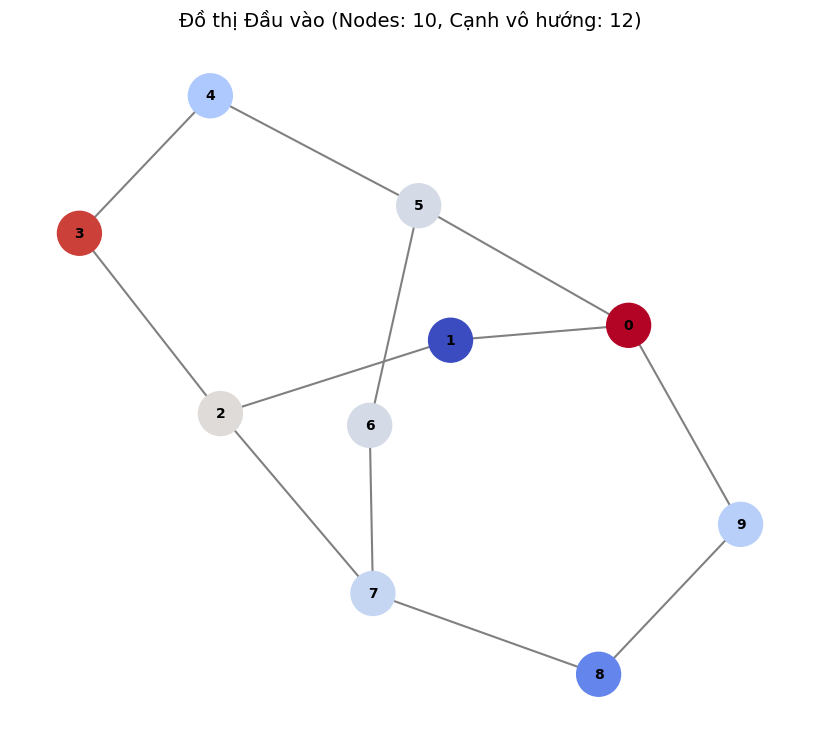


--- 3. Node Embeddings ---
Kích thước Node Embeddings: torch.Size([10, 16])
tensor([[-9.6600e-02,  3.5623e-03, -7.6677e-02,  8.5158e-02,  1.0221e-01,
         -5.9899e-02, -2.5397e-02, -8.4968e-03, -5.7023e-02,  5.5334e-02,
          6.1760e-02,  1.1510e-01,  6.7630e-02, -3.8421e-02,  4.5179e-02,
         -1.8754e-02],
        [ 7.7482e-03,  3.9838e-02, -8.9594e-03,  1.2867e-01,  2.8331e-02,
         -1.1053e-01,  2.7810e-02, -3.9620e-02, -1.1777e-01,  3.8849e-02,
          7.9643e-02, -4.8987e-02,  1.4222e-01, -9.5481e-03,  5.8059e-03,
         -1.7254e-02],
        [-3.9450e-02,  1.2272e-01,  6.3830e-02,  2.7310e-01, -6.3916e-03,
         -2.4033e-01,  3.9305e-02, -1.0491e-01, -3.1472e-01,  5.9135e-02,
          1.1439e-01, -3.1554e-01,  3.2991e-01, -1.5728e-02,  5.0544e-02,
          8.0942e-05],
        [-5.9093e-02,  9.0130e-02,  4.4427e-02,  3.7443e-01, -1.3580e-01,
         -3.8205e-01,  7.2371e-02, -2.1629e-01, -5.5083e-01,  1.1929e-01,
          1.9994e-01, -7.0287e-01,  5.39

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ====================================================================
# --- CÁC HÀM HỖ TRỢ VÀ MÔ HÌNH ---
# ====================================================================

def draw_graph(data, title="Đồ thị Đầu vào"):
    """Vẽ đồ thị đầu vào bằng NetworkX và Matplotlib."""
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))

    # Thêm các cạnh (chỉ thêm một chiều vì nx.Graph là vô hướng)
    for i in range(data.edge_index.shape[1]):
        u = data.edge_index[0, i].item()
        v = data.edge_index[1, i].item()
        if u < v:
            g.add_edge(u, v)

    # Lấy đặc trưng đầu tiên (cột 0) để tô màu node
    node_colors = 'lightblue'
    if data.x.dim() > 1 and data.x.shape[1] > 0:
        node_colors = data.x[:, 0].numpy()

    plt.figure(figsize=(8, 7))
    pos = nx.spring_layout(g, seed=42)

    nx.draw(g, pos, with_labels=True,
            node_color=node_colors,
            cmap=plt.cm.coolwarm,
            node_size=1000,
            font_size=10, font_weight='bold',
            edge_color='gray', width=1.5)

    plt.title(title, fontsize=14)
    plt.show()

class GNN_Node_Embed(torch.nn.Module):
    """Mô hình GNN cơ bản để tạo Node Embeddings."""
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        node_embeddings = self.conv2(x, edge_index)
        return node_embeddings

class GNN_Graph_Embed(GNN_Node_Embed):
    """Kế thừa GNN_Node_Embed và thêm Global Pooling để tạo Graph Embedding."""
    def __init__(self, in_channels, hidden_channels, node_embed_dim, graph_embed_dim):
        super().__init__(in_channels, hidden_channels, node_embed_dim)
        self.lin = torch.nn.Linear(node_embed_dim, graph_embed_dim)

    def forward(self, x, edge_index, batch):
        # 1. Tính Node Embeddings
        node_embeddings = super().forward(x, edge_index)

        # 2. Global Pooling
        pooled_embedding = global_mean_pool(node_embeddings, batch)

        # 3. Lớp Linear
        graph_embedding = self.lin(pooled_embedding)

        return node_embeddings, graph_embedding

# ====================================================================
# --- KHỞI TẠO, TÍNH TOÁN VÀ LƯU TRỮ ---
# ====================================================================

# --- 1. CHUẨN BỊ DỮ LIỆU (10 Nodes, 12 Cặp Cạnh Vô Hướng) ---

NUM_NODES = 10
IN_CHANNELS = 3
torch.manual_seed(42)
x = torch.randn(NUM_NODES, IN_CHANNELS, dtype=torch.float)

# 12 cặp cạnh vô hướng (24 cạnh có hướng)
edge_list_undirected = torch.tensor([
    [0, 1], [1, 2], [2, 3], [3, 4], [4, 5],
    [5, 6], [6, 7], [7, 8], [8, 9], [9, 0], # Vòng tròn
    [0, 5], [2, 7] # Các cạnh chéo
], dtype=torch.long)

# Tạo edge_index có hướng (kích thước [2, 24])
edge_index = torch.cat([
    edge_list_undirected,
    edge_list_undirected.flip(dims=[1]) # Cạnh ngược lại (v -> u)
], dim=0).t().contiguous()

data = Data(x=x, edge_index=edge_index)

print("--- 1. Thông tin Dữ liệu Đồ thị (10 Nodes) ---")
print(data)
print(f"Tổng số cạnh (có hướng): {data.edge_index.shape[1]}")

# --- GỌI HÀM VẼ ĐỒ THỊ ---
draw_graph(data, f"Đồ thị Đầu vào (Nodes: {data.num_nodes}, Cạnh vô hướng: {data.edge_index.shape[1]//2})")

# --- 2. KHỞI TẠO VÀ TÍNH TOÁN EMBEDDINGS ---

HIDDEN_CHANNELS = 32
NODE_EMBED_DIM = 16
GRAPH_EMBED_DIM = 8

model = GNN_Graph_Embed(IN_CHANNELS, HIDDEN_CHANNELS, NODE_EMBED_DIM, GRAPH_EMBED_DIM)

# Tensor 'batch' (tất cả nodes thuộc đồ thị 0)
batch = torch.zeros(data.num_nodes, dtype=torch.long)

model.eval()
with torch.no_grad():
    node_embeddings_result, graph_embedding_result = model(data.x, data.edge_index, batch)

# --- 3. HIỂN THỊ KẾT QUẢ ---

print("\n--- 3. Node Embeddings ---")
print(f"Kích thước Node Embeddings: {node_embeddings_result.shape}")
print(node_embeddings_result)

print("\n--- 4. Graph Embedding ---")
print(f"Kích thước Graph Embedding: {graph_embedding_result.shape}")
print(graph_embedding_result)

# --- 4. LƯU KẾT QUẢ VÀO FILE TEXT ---

print("\n--- 5. Lưu Embeddings vào File ---")

node_embeddings_np = node_embeddings_result.numpy()
graph_embedding_np = graph_embedding_result.numpy()

# Lưu Node Embeddings
node_file_name = "nodeEmbeddings.txt"
try:
    with open(node_file_name, 'w') as f:
        for i, row in enumerate(node_embeddings_np):
            row_str = ' '.join([f'{val:.6f}' for val in row])
            f.write(f'Node_{i}: {row_str}\n')

    print(f"✅ Đã lưu Node Embeddings vào file: **{node_file_name}**")
except Exception as e:
    print(f"❌ Lỗi khi lưu Node Embeddings: {e}")


# Lưu Graph Embedding
graph_file_name = "GraphEmbedding.txt"
try:
    with open(graph_file_name, 'w') as f:
        row = graph_embedding_np[0]
        row_str = ' '.join([f'{val:.6f}' for val in row])
        f.write(f'Graph_Embedding: {row_str}\n')

    print(f"✅ Đã lưu Graph Embedding vào file: **{graph_file_name}**")
except Exception as e:
    print(f"❌ Lỗi khi lưu Graph Embedding: {e}")